# 05 · Neural Network Initialization — Code

We build a genuinely **deep** network (15 layers) with three initialization schemes and watch what happens to activation magnitude, layer by layer, on the forward pass — this is the cleanest way to *see* vanishing/exploding behavior before we even touch backprop.

Part A: NumPy from scratch. Part B: PyTorch (`torch.nn.init`).

# Part A — NumPy From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

NUM_LAYERS = 15
LAYER_SIZE = 100

def build_weights(init_scheme, activation, num_layers=NUM_LAYERS, layer_size=LAYER_SIZE):
    """init_scheme: 'naive_large' | 'naive_small' | 'xavier' | 'he' """
    weights = []
    for _ in range(num_layers):
        fan_in = fan_out = layer_size
        if init_scheme == 'naive_large':
            W = np.random.randn(fan_in, fan_out) * 1.0          # too large
        elif init_scheme == 'naive_small':
            W = np.random.randn(fan_in, fan_out) * 0.01          # too small
        elif init_scheme == 'xavier':
            W = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / (fan_in + fan_out))
        elif init_scheme == 'he':
            W = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
        else:
            raise ValueError(init_scheme)
        weights.append(W)
    return weights

def forward_track(X, weights, activation_fn):
    """Run X through every layer, recording the std of activations at each depth."""
    a = X
    stds = [a.std()]
    for W in weights:
        z = a @ W
        a = activation_fn(z)
        stds.append(a.std())
    return stds

X = np.random.randn(500, LAYER_SIZE)  # 500 "samples" of random input, matching layer width

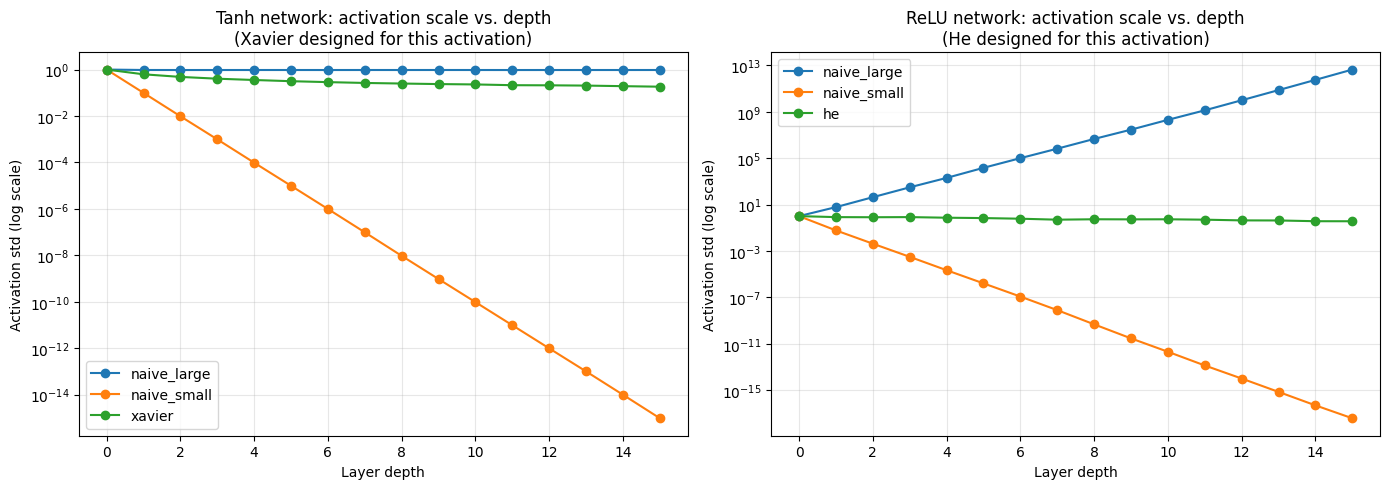

naive_small: activation std collapses toward 0 with depth -> VANISHING
naive_large: activation std explodes with depth -> EXPLODING
xavier (tanh) / he (relu): activation std stays roughly CONSTANT across all 15 layers


In [2]:
schemes_tanh = ['naive_large', 'naive_small', 'xavier']
schemes_relu = ['naive_large', 'naive_small', 'he']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scheme in schemes_tanh:
    weights = build_weights(scheme, 'tanh')
    stds = forward_track(X, weights, tanh)
    axes[0].plot(stds, marker='o', label=scheme)
axes[0].set_yscale('log')
axes[0].set_xlabel("Layer depth"); axes[0].set_ylabel("Activation std (log scale)")
axes[0].set_title("Tanh network: activation scale vs. depth\n(Xavier designed for this activation)")
axes[0].legend(); axes[0].grid(alpha=0.3)

for scheme in schemes_relu:
    weights = build_weights(scheme, 'relu')
    stds = forward_track(X, weights, relu)
    axes[1].plot(stds, marker='o', label=scheme)
axes[1].set_yscale('log')
axes[1].set_xlabel("Layer depth"); axes[1].set_ylabel("Activation std (log scale)")
axes[1].set_title("ReLU network: activation scale vs. depth\n(He designed for this activation)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("naive_small: activation std collapses toward 0 with depth -> VANISHING")
print("naive_large: activation std explodes with depth -> EXPLODING")
print("xavier (tanh) / he (relu): activation std stays roughly CONSTANT across all 15 layers")

## Now the gradient side: does vanishing/exploding activation also mean vanishing/exploding gradient?

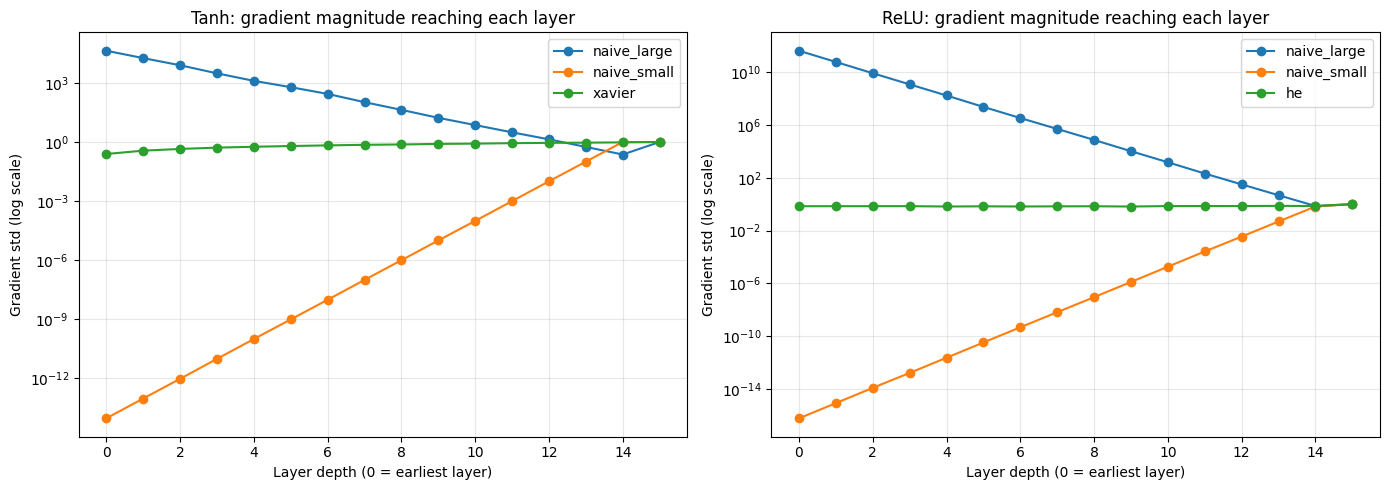

With naive_small init, the gradient reaching the EARLIEST layers (left side, depth 0) is
many orders of magnitude smaller than at the output -- this is the vanishing gradient problem,
and it's exactly why early layers in a badly-initialized deep net barely learn anything.


In [3]:
def forward_backward_track(X, weights, activation_fn, activation_derivative_fn):
    """Forward pass (caching z, a per layer), then backprop a dummy loss gradient
    all the way back to the input, recording the gradient's std at each layer."""
    a = X
    zs, as_ = [], [a]
    for W in weights:
        z = a @ W
        a = activation_fn(z)
        zs.append(z); as_.append(a)

    # pretend the "loss gradient" arriving at the last layer is just random unit noise
    grad = np.random.randn(*a.shape)
    grad_stds = [grad.std()]
    for i in reversed(range(len(weights))):
        grad = grad * activation_derivative_fn(zs[i])
        grad_stds.append(grad.std())
        grad = grad @ weights[i].T
    return grad_stds[::-1]   # reverse so index 0 = earliest layer, matching forward plot order

def tanh_derivative_from_z(z):
    return 1 - np.tanh(z)**2

def relu_derivative_from_z(z):
    return (z > 0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scheme in schemes_tanh:
    weights = build_weights(scheme, 'tanh')
    grad_stds = forward_backward_track(X, weights, tanh, tanh_derivative_from_z)
    axes[0].plot(grad_stds, marker='o', label=scheme)
axes[0].set_yscale('log')
axes[0].set_xlabel("Layer depth (0 = earliest layer)"); axes[0].set_ylabel("Gradient std (log scale)")
axes[0].set_title("Tanh: gradient magnitude reaching each layer")
axes[0].legend(); axes[0].grid(alpha=0.3)

for scheme in schemes_relu:
    weights = build_weights(scheme, 'relu')
    grad_stds = forward_backward_track(X, weights, relu, relu_derivative_from_z)
    axes[1].plot(grad_stds, marker='o', label=scheme)
axes[1].set_yscale('log')
axes[1].set_xlabel("Layer depth (0 = earliest layer)"); axes[1].set_ylabel("Gradient std (log scale)")
axes[1].set_title("ReLU: gradient magnitude reaching each layer")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("With naive_small init, the gradient reaching the EARLIEST layers (left side, depth 0) is")
print("many orders of magnitude smaller than at the output -- this is the vanishing gradient problem,")
print("and it's exactly why early layers in a badly-initialized deep net barely learn anything.")

---
# Part B — PyTorch Equivalent (`torch.nn.init`)

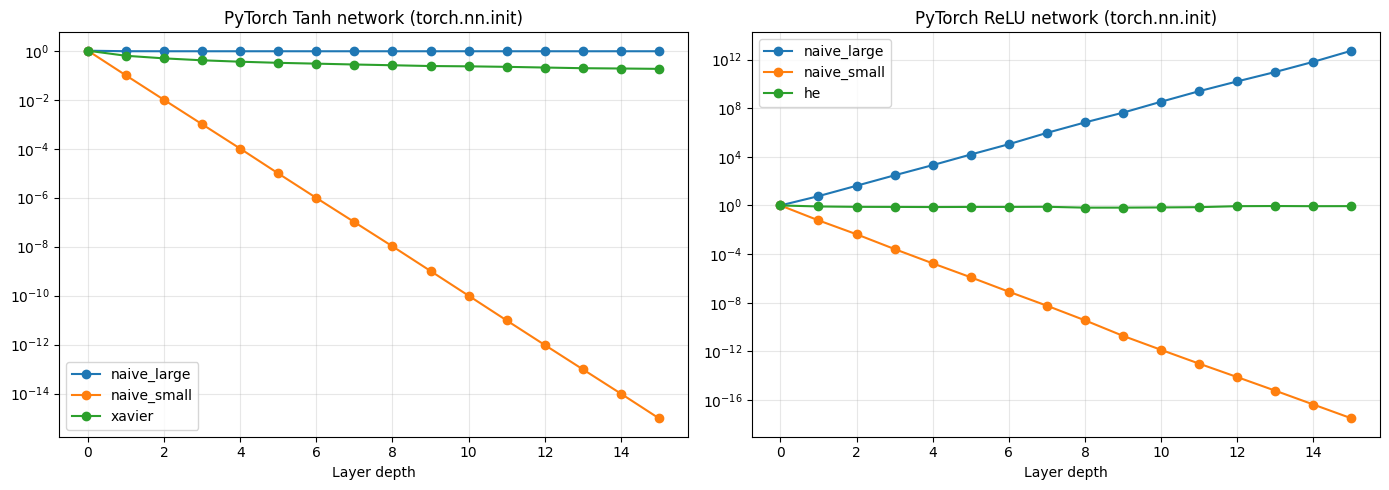

Same story as Part A, using PyTorch's built-in xavier_normal_ and kaiming_normal_ (He) initializers.


In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

def build_torch_net(init_scheme, activation, num_layers=15, layer_size=100):
    layers = []
    for _ in range(num_layers):
        linear = nn.Linear(layer_size, layer_size, bias=False)
        if init_scheme == 'naive_large':
            nn.init.normal_(linear.weight, mean=0.0, std=1.0)
        elif init_scheme == 'naive_small':
            nn.init.normal_(linear.weight, mean=0.0, std=0.01)
        elif init_scheme == 'xavier':
            nn.init.xavier_normal_(linear.weight)          # <-- built-in Xavier/Glorot
        elif init_scheme == 'he':
            nn.init.kaiming_normal_(linear.weight, nonlinearity='relu')  # <-- built-in He/Kaiming
        layers.append(linear)
        layers.append(activation())
    return nn.ModuleList(layers)

def torch_forward_track(X, net):
    a = X
    stds = [a.std().item()]
    for layer in net:
        a = layer(a)
        if isinstance(layer, (nn.Tanh, nn.ReLU)):   # record after each activation
            stds.append(a.std().item())
    return stds

X_t = torch.randn(500, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for scheme in ['naive_large', 'naive_small', 'xavier']:
    net = build_torch_net(scheme, nn.Tanh)
    stds = torch_forward_track(X_t, net)
    axes[0].plot(stds, marker='o', label=scheme)
axes[0].set_yscale('log'); axes[0].set_title("PyTorch Tanh network (torch.nn.init)")
axes[0].set_xlabel("Layer depth"); axes[0].legend(); axes[0].grid(alpha=0.3)

for scheme in ['naive_large', 'naive_small', 'he']:
    net = build_torch_net(scheme, nn.ReLU)
    stds = torch_forward_track(X_t, net)
    axes[1].plot(stds, marker='o', label=scheme)
axes[1].set_yscale('log'); axes[1].set_title("PyTorch ReLU network (torch.nn.init)")
axes[1].set_xlabel("Layer depth"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Same story as Part A, using PyTorch's built-in xavier_normal_ and kaiming_normal_ (He) initializers.")